## Project: Breast Cancer Classification using Logistic Regression

### 1. Problem Statement
We want to classify whether a tumor is malignant (cancerous = 0) or benign (non-cancerous = 1) using machine learning.
This is a binary classification problem.

### 2. Dataset Loading
We use the Breast Cancer Wisconsin dataset from scikit-learn.

In [1]:
from sklearn import datasets

# Load dataset
data = datasets.load_breast_cancer()

# Define features (X) and target (y)
X = data.data        # 30 numerical features
y = data.target      # 0 = malignant, 1 = benign

print("Dataset shape:", X.shape, y.shape)
print("Feature names:", data.feature_names[:5], "...")  # show first 5 features

Dataset shape: (569, 30) (569,)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness'] ...


#### Explanation:

* 569 samples, 30 features.

* Features include radius, texture, perimeter, area, smoothness, etc.

* Target is binary (0 or 1).

### 3. Train-Test Split
We split data into training (80%) and testing (20%).

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (455, 30) (455,)
Testing set shape: (114, 30) (114,)


#### Explanation:

* Training set: 455 samples.

* Testing set: 114 samples.

**Purpose:** Evaluate model on unseen data to avoid overfitting.

### 4. Standard Scaling
Logistic Regression works better when features are scaled.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data (without fitting again)
X_test_scaled = scaler.transform(X_test)

print("Scaled training set shape:", X_train_scaled.shape)

Scaled training set shape: (455, 30)


#### Explanation:

* StandardScaler converts features to mean = 0, std = 1.

* Prevents large-scale features (like area) from dominating.

### 5. Model Training
We train a Logistic Regression model.

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
print("First 10 predictions:", y_pred[:10])

First 10 predictions: [1 0 0 1 1 0 0 0 1 1]


#### Explanation:

* Logistic Regression is a good baseline for binary classification.

* Outputs probabilities between 0 and 1, then classifies.

### 6. Evaluation Metrics
We evaluate accuracy, confusion matrix, classification report, and ROC-AUC.

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# ROC-AUC Score
auc = roc_auc_score(y_test, y_pred)
print("AUC Score:", auc)

Accuracy: 0.9736842105263158
Confusion Matrix:
 [[41  2]
 [ 1 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

AUC Score: 0.969701932525385


#### Explanation:

* Accuracy ≈ 97.36% → Model correctly classified ~97% of cases.

* Confusion Matrix: TN=41, TP=70, FP=2, FN=1.

* Recall ≈ 98.6% → Almost all cancer cases detected.

* F1 ≈ 97.9% → Balanced precision and recall.

* AUC ≈ 0.97 → Excellent discrimination ability.

### 7. Visualizations
Separate plots for metrics, confusion matrix, and ROC curve.

/tmp/ipython-input-3273685960.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="viridis")


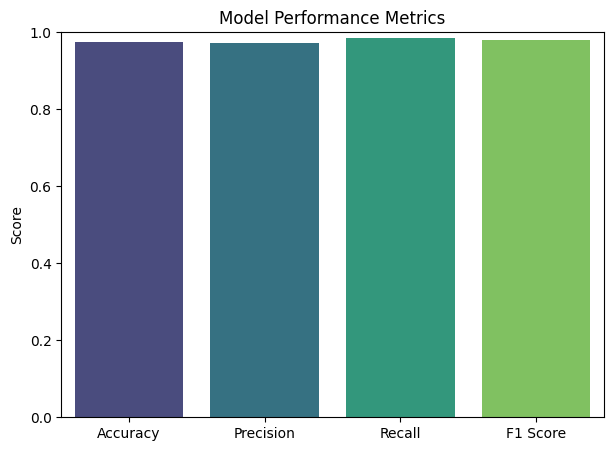

In [10]:
from sklearn.metrics import precision_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Bar Chart with all four metrics
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="viridis")
plt.ylim(0,1)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.show()

### Explanation
* Accuracy → Overall correctness (~97%).

* Precision → Out of predicted positives, how many were correct (~97%).

* Recall → Out of actual positives, how many were detected (~98.6%).

* F1 Score → Balance between precision and recall (~97.9%).

Adding precision makes the visualization complete and shows the trade-off between catching all cancer cases (recall) and avoiding false alarms (precision).

“Initially, my bar chart only showed accuracy, recall, and F1 score. I added precision to give a complete view of model performance. This is important in medical datasets because precision tells us how often the model’s positive predictions are correct, while recall tells us how many actual cancer cases we detect. Together with F1, this gives a balanced picture.”

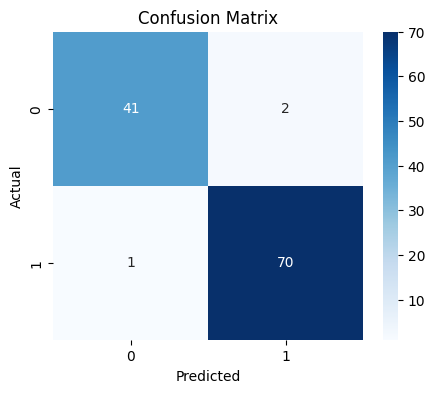

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Explanation of the Graph
* Confusion Matrix Layout:

  * Top-left (41) → True Negatives (TN): correctly predicted malignant cases.

  * Top-right (2) → False Positives (FP): predicted benign but actually malignant.

  * Bottom-left (1) → False Negatives (FN): predicted malignant but actually benign.

  * Bottom-right (70) → True Positives (TP): correctly predicted benign cases.

* Color Intensity:

  * Darker blue = higher counts (e.g., 70 true positives).

  * Lighter blue = lower counts (e.g., 1 false negative).

* Interpretation:

  * The model performs very well, with only 3 misclassifications (2 FP, 1 FN).

  * In medical datasets, false negatives (FN) are most dangerous because they mean a cancer case could go undetected.

  “This confusion matrix heatmap shows how my model classified malignant vs benign tumors. Out of 114 test cases, it correctly identified 41 malignant and 70 benign. There were only 2 false positives and 1 false negative. The false negative is critical in healthcare because it means a cancer case could be missed. This visualization makes it easy to see both the strengths and weaknesses of the model.”

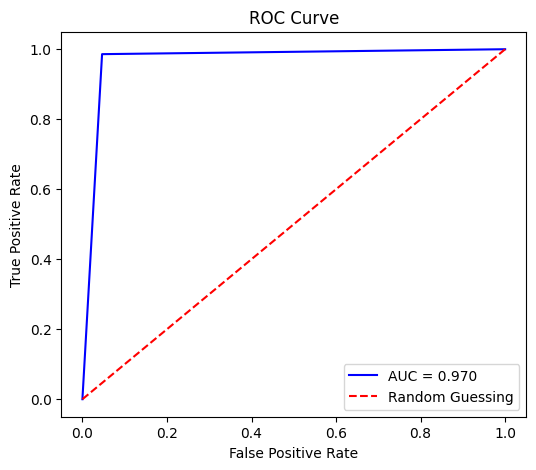

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], color='red', linestyle='--', label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Explanation of the Graph
* X-axis (False Positive Rate): How often the model incorrectly predicts malignant as benign.

* Y-axis (True Positive Rate): How often the model correctly detects cancer cases.

* Blue Curve: Shows the trade-off between sensitivity (recall) and specificity.

* Red Dashed Line: Represents random guessing (AUC = 0.5).

* AUC ≈ 0.97: Means the model has excellent discrimination ability between malignant and benign tumors.

“This ROC curve shows how well my model distinguishes between malignant and benign tumors. The blue curve is close to the top-left corner, which indicates strong performance. The AUC score of 0.97 means the model has excellent discrimination ability. In medical datasets, this is crucial because it shows the model can reliably separate cancerous from non-cancerous cases.”